MEISY DWI PUTRI (4212201014)
ASESMEN AKHIR SEMESTER

***Klasifikasi Karakter Tulisan Tangan pada Dataset EMNIST (Extended MNIST) menggunakan Convolutional Neural Network (CNN)***

***IMPORT LIBRARY***

In [4]:
import pandas as pd
import torch
import numpy as np
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from torch import nn, optim
from PIL import Image
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score
from tqdm import tqdm
import matplotlib.pyplot as plt


***Load Dataset***

In [6]:
train_data_path ='/content/emnist-bymerge-train.csv'
val_data_path ='/content/emnist-bymerge-test.csv'
data_train = pd.read_csv(train_data_path, header=None, nrows=500)
data_val = pd.read_csv(val_data_path, header=None, nrows=500)
print("Dataset loaded successfully.")


Dataset loaded successfully.


***Dataset*** ***Class***

In [7]:
def preprocess_image(data):
    data = np.clip(data, 0, 255).astype(np.uint8).reshape(28, 28)
    return Image.fromarray(data).convert("RGB")

class CustomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        label = self.dataframe.iloc[idx, 0]
        img_data = self.dataframe.iloc[idx, 1:].values
        image = preprocess_image(img_data)
        if self.transform:
            image = self.transform(image)
        return image, label

***Tansformations***

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

***Load Datasets***

In [9]:
train_dataset = CustomDataset(data_train, transform=transform)
val_dataset = CustomDataset(data_val, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

***Initialize Model***

In [10]:
model = models.alexnet(pretrained=True)
model.classifier[6] = nn.Linear(4096, 200)
for param in model.features.parameters():
    param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
device = torch.device('cpu')
model.to(device)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:02<00:00, 108MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

***Training Loop***

In [12]:
num_epochs = 15
train_losses, train_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    epoch_loss, corrects = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * inputs.size(0)
        corrects += torch.sum(torch.argmax(outputs, dim=1) == labels)

    epoch_loss /= len(train_dataset)
    epoch_accuracy = corrects.double() / len(train_dataset)
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy.cpu().item())

    print(f"Epoch {epoch+1}/{num_epochs}: Loss = {epoch_loss:.4f}, Accuracy = {epoch_accuracy:.4f}")

Epoch 1/15: Loss = 3.3044, Accuracy = 0.2300
Epoch 2/15: Loss = 1.7039, Accuracy = 0.5460
Epoch 3/15: Loss = 1.0914, Accuracy = 0.6700
Epoch 4/15: Loss = 0.6996, Accuracy = 0.7720
Epoch 5/15: Loss = 0.5215, Accuracy = 0.8380
Epoch 6/15: Loss = 0.3616, Accuracy = 0.8800
Epoch 7/15: Loss = 0.3366, Accuracy = 0.8900
Epoch 8/15: Loss = 0.2679, Accuracy = 0.9100
Epoch 9/15: Loss = 0.2358, Accuracy = 0.9300
Epoch 10/15: Loss = 0.2122, Accuracy = 0.9220
Epoch 11/15: Loss = 0.2130, Accuracy = 0.9320
Epoch 12/15: Loss = 0.1894, Accuracy = 0.9380
Epoch 13/15: Loss = 0.1556, Accuracy = 0.9400
Epoch 14/15: Loss = 0.1505, Accuracy = 0.9560
Epoch 15/15: Loss = 0.1454, Accuracy = 0.9520


***Plot training loss and accuracy***

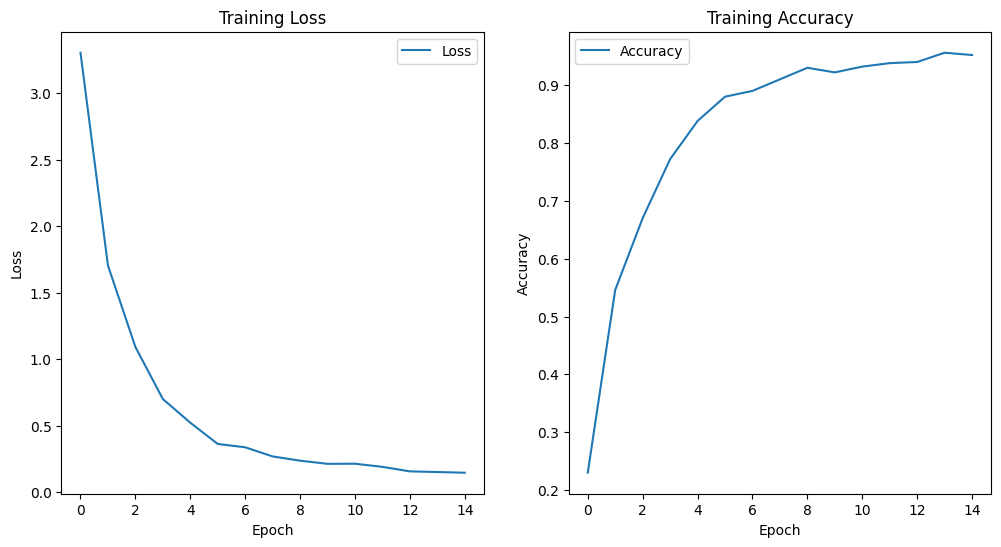

In [13]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score

***Leave-One-Out Cross Validation (LOOCV) Implementation***

In [14]:
loo = LeaveOneOut()
data_array = data_train.to_numpy()
all_preds, all_labels = [], []

print("Starting LOOCV...")

for train_idx, test_idx in tqdm(loo.split(data_array)):
    train_samples = data_array[train_idx]
    test_sample = data_array[test_idx]

    # Create datasets and dataloaders
    train_dataset = CustomDataset(pd.DataFrame(train_samples), transform=transform)
    test_dataset = CustomDataset(pd.DataFrame(test_sample), transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

Starting LOOCV...


500it [00:00, 591.05it/s]


***Reinitialize the model and optimizer for each LOOCV iteration***

In [18]:
model = models.alexnet(pretrained=True)
model.classifier[6] = nn.Linear(4096, 200)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


***Train on train_loader***

In [20]:
model.train()
for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()


***Test on test_loader***

In [22]:
model.eval()
with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            all_preds.append(torch.argmax(outputs, dim=1).cpu().item())
            all_labels.append(labels.cpu().item())


***Calculate Evaluation Metrics***

In [23]:
conf_matrix = confusion_matrix(all_labels, all_preds)
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro')

print("\nEvaluation Results:")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score: {f1:.4f}")



Evaluation Results:
Confusion Matrix:
[[1]]
Accuracy: 1.0000
Precision: 1.0000
F1-Score: 1.0000


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
